In [1]:
import os, random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
from torchvision import transforms
from torchsummary import summary
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from sklearn.model_selection import train_test_split

import qiskit
from qiskit.circuit.library import RealAmplitudes, NLocal, ZZFeatureMap
from qiskit.circuit import QuantumCircuit, QuantumRegister, ClassicalRegister, Parameter, ParameterVector
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN

In [2]:
max_in_class = 200
train_part = 0.5
noise = 0.1
batch_size = 30
reps = 1
num_qubit = 1

epochs = 200
initial_lr = 0.01

device = "cpu"

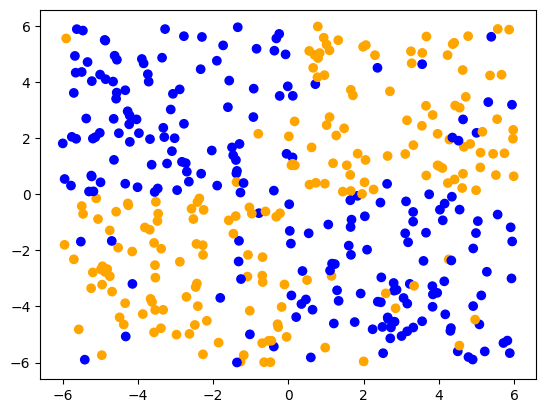

In [3]:
data = []
labels = []

def label_with_noise(label = 0, noise = 0):
    if(random.random() < noise):
        labels.append(1-label)
    else:
        labels.append(label)

for i in range(int(max_in_class/2)):
    data.append([random.uniform(-6.0, 0), random.uniform(-6.0, 0)])
    data.append([random.uniform(0, 6.0), random.uniform(0, 6.0)])
    data.append([random.uniform(-6.0, 0), random.uniform(0, 6.0)])
    data.append([random.uniform(0, 6.0), random.uniform(-6.0, 0)])
    label_with_noise(1, noise)
    label_with_noise(1, noise)
    label_with_noise(0, noise)
    label_with_noise(0, noise)

x, y = zip(*data)

plt.scatter(x, y,
            c = labels,
            cmap = mcolors.ListedColormap(["b", "orange"]))

In [4]:
class MyDataset(Dataset):
    def __init__(self):
        self.data = torch.tensor(data)
        self.labels = torch.tensor(labels)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

dataset = MyDataset()
train_data, test_data = train_test_split(dataset, train_size=train_part, random_state=0)
train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=True)
print(len(train_dataloader.dataset), len(test_dataloader.dataset))

#for batch in dataloader:
#    print("Batch Data:", batch[0])  
#    print("Batch Labels:", batch[1])

200 200


In [5]:
class InitialStateQC:
    def __init__(self, n_qubits):
        self._circuit = qiskit.QuantumCircuit(n_qubits)
        params = ParameterVector('φ', n_qubits)
        
        for i in range(n_qubits):
            self._circuit.rx(np.pi/2 + params[i], i)#


class MyQuantumCircuit:
    def __init__(self, n_qubits, reps = 2):
        self._circuit = qiskit.QuantumCircuit(n_qubits)
        params = ParameterVector('Ψ', n_qubits*reps*2)#*2
        
        for i in range(n_qubits):
            for r in range(reps):
                self._circuit.ry(params[r*i+r], i)
                self._circuit.rz(params[r*i+r + n_qubits*reps], i)

def create_qnn(num_qubit = 2, reps = 3):
    feature_map = InitialStateQC(num_qubit)._circuit
    ansatz = MyQuantumCircuit(num_qubit, reps = reps)._circuit
    qc = QuantumCircuit(num_qubit)
    qc.compose(feature_map, inplace=True)
    qc.compose(ansatz, inplace=True)

    qnn = SamplerQNN(#SamplerQNN
        circuit = qc,
        sampler = None,
        input_params=feature_map.parameters,
        weight_params=ansatz.parameters,
        input_gradients=True
    )
    return qnn


qnn = create_qnn(num_qubit, reps)

C:\Users\ivlev\AppData\Local\Temp\ipykernel_22856\423785393.py:27: DeprecationWarning: V1 Primitives are deprecated as of qiskit-machine-learning 0.8.0 and will be removed no sooner than 4 months after the release date. Use V2 primitives for continued compatibility and support.
  qnn = SamplerQNN(#SamplerQNN


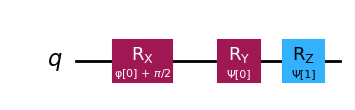

In [6]:
qnn.circuit.draw("mpl")

In [7]:
tens_1 = torch.Tensor([[1]]*batch_size)

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.qnn = TorchConnector(qnn)

    def forward(self, x):
        x = self.qnn(x)
        return x

In [8]:
model = SimpleNN()
#summary(model, (2,1), batch_size, device = device)
print(model)

SimpleNN(
  (qnn): TorchConnector()
)


In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
loss_fn = nn.CrossEntropyLoss()

In [10]:
def data_prep(X):
    data_X = []
    for i in range(len(X)):
        data_X.append([X[i][0]*X[i][1]/36])
    return torch.tensor(data_X).to(device)

In [11]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.train()
    train_loss, correct = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(data_prep(X))
        loss = loss_fn(pred, y)

        train_loss += loss_fn(pred, y).item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    if batch % 100 == 0:
        loss, current = loss.item(), (batch + 1) * len(X)
        print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    
    train_loss /= num_batches
    correct /= size

    return correct, train_loss

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(data_prep(X))
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

    return correct, test_loss

In [12]:
history = {
    'train_loss':[],
    'train_accuracy':[],
    'val_loss':[],
    'val_accuracy':[],
    'test_loss':[],
    'test_accuracy':[]
}

for t in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0
    print(f"Epoch {t+1}\n-------------------------------")
    acc, loss = train(train_dataloader, model, loss_fn, optimizer)
    history['train_accuracy'].append(acc)
    history['train_loss'].append(loss)
    acc, loss = test(test_dataloader, model, loss_fn)
    history['val_accuracy'].append(acc)
    history['val_loss'].append(loss)
print("Done!")

Epoch 1
-------------------------------
Test Error: 
 Accuracy: 90.5%, Avg loss: 0.637158 

Epoch 2
-------------------------------
Test Error: 
 Accuracy: 90.5%, Avg loss: 0.634489 

Epoch 3
-------------------------------
Test Error: 
 Accuracy: 90.5%, Avg loss: 0.629935 

Epoch 4
-------------------------------
Test Error: 
 Accuracy: 90.5%, Avg loss: 0.627329 

Epoch 5
-------------------------------
Test Error: 
 Accuracy: 90.5%, Avg loss: 0.624546 

Epoch 6
-------------------------------
Test Error: 
 Accuracy: 90.5%, Avg loss: 0.623782 

Epoch 7
-------------------------------
Test Error: 
 Accuracy: 90.5%, Avg loss: 0.621890 

Epoch 8
-------------------------------
Test Error: 
 Accuracy: 90.5%, Avg loss: 0.619651 

Epoch 9
-------------------------------
Test Error: 
 Accuracy: 90.5%, Avg loss: 0.619723 

Epoch 10
-------------------------------
Test Error: 
 Accuracy: 90.5%, Avg loss: 0.617263 

Epoch 11
-------------------------------
Test Error: 
 Accuracy: 90.5%, Avg los

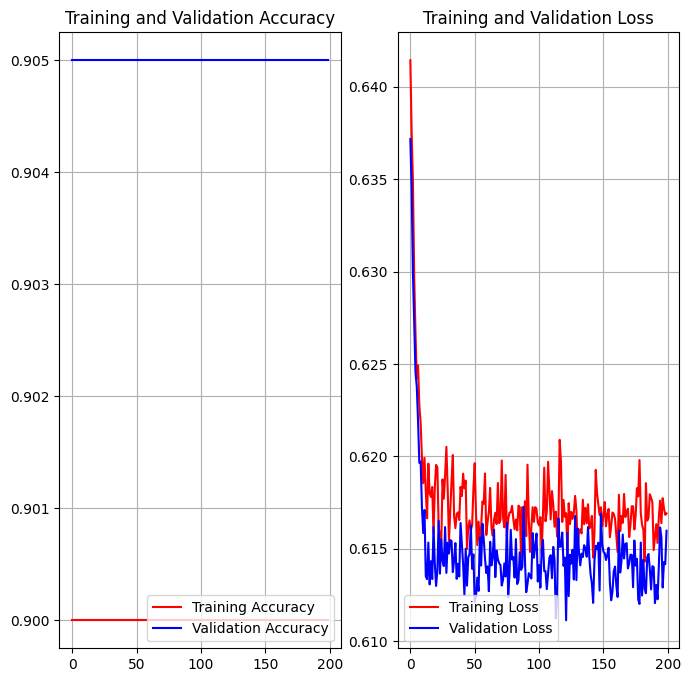

In [13]:
epochs_range = range(epochs)
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_accuracy'], label='Training Accuracy', color='red')
plt.plot(epochs_range, history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_loss'], label='Training Loss', color='red')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', color='blue')
plt.legend(loc='lower left')
plt.title('Training and Validation Loss')
plt.grid()
plt.show()

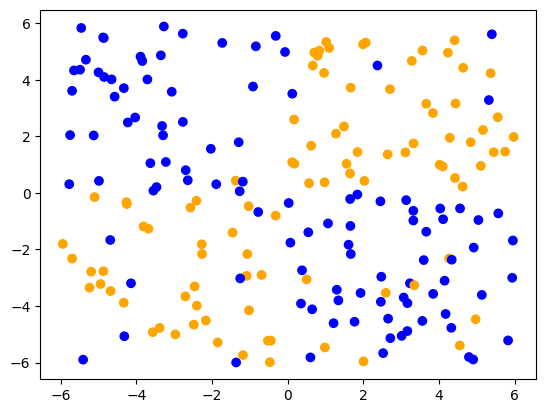

In [14]:
xy, l = zip(*train_dataloader.dataset)
x, y = zip(*xy)

plt.scatter(x, y,
            c = l,
            cmap = mcolors.ListedColormap(["b", "orange"]))

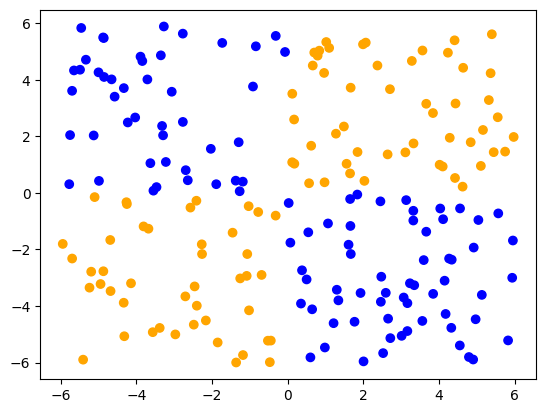

In [15]:
pred = model(data_prep(xy))
plt.scatter(x, y,
            c = pred.argmax(1),
            cmap = mcolors.ListedColormap(["b", "orange"]))

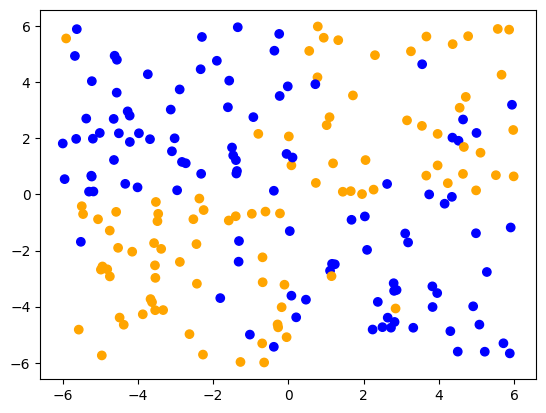

In [16]:
xy, l = zip(*test_dataloader.dataset)
x, y = zip(*xy)

plt.scatter(x, y,
            c = l,
            cmap = mcolors.ListedColormap(["b", "orange"]))

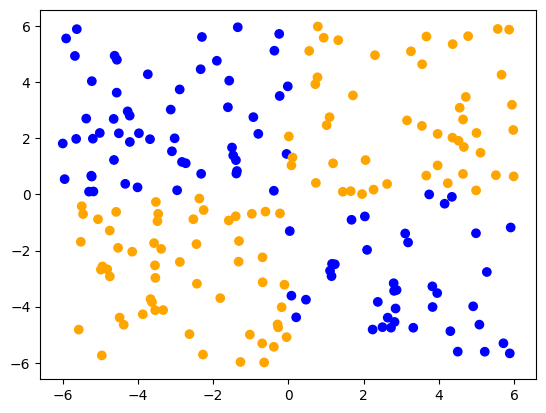

In [17]:
pred = model(data_prep(xy))
plt.scatter(x, y,
            c = pred.argmax(1),
            cmap = mcolors.ListedColormap(["b", "orange"]))

In [18]:
print(model.state_dict())

OrderedDict({'qnn.weight': tensor([ 2.3418e-17, -8.0613e-01]), 'qnn._weights': tensor([ 2.3418e-17, -8.0613e-01])})
